In [ ]:
DB_PATH = "./fraud_demo.sqlite3"

import sqlite3
from datetime import datetime, timedelta


def init_database(path: str = DB_PATH):
    conn = sqlite3.connect(path)
    cur = conn.cursor()

    cur.executescript(
        """
        DROP TABLE IF EXISTS users;
        DROP TABLE IF EXISTS orders;
        DROP TABLE IF EXISTS order_items;
        DROP TABLE IF EXISTS returns;
        """
    )

    cur.executescript(
        """
        CREATE TABLE users (
            email TEXT PRIMARY KEY,
            full_name TEXT NOT NULL
        );

        CREATE TABLE orders (
            order_id TEXT PRIMARY KEY,
            user_email TEXT NOT NULL,
            order_date TEXT NOT NULL,
            status TEXT NOT NULL,
            total_amount REAL NOT NULL,
            FOREIGN KEY(user_email) REFERENCES users(email)
        );

        CREATE TABLE order_items (
            order_item_id INTEGER PRIMARY KEY AUTOINCREMENT,
            order_id TEXT NOT NULL,
            product_id TEXT NOT NULL,
            quantity INTEGER NOT NULL,
            unit_price REAL NOT NULL,
            FOREIGN KEY(order_id) REFERENCES orders(order_id)
        );

        CREATE TABLE returns (
            return_id TEXT PRIMARY KEY,
            order_id TEXT NOT NULL,
            user_email TEXT NOT NULL,
            return_date TEXT NOT NULL,
            reason TEXT NOT NULL,
            status TEXT NOT NULL,
            refund_amount REAL,
            FOREIGN KEY(order_id) REFERENCES orders(order_id),
            FOREIGN KEY(user_email) REFERENCES users(email)
        );
        """
    )

    users = [
        ("good_user@example.com", "Good User"),
        ("fraudster@example.com", "Frequent Returner"),
    ]
    cur.executemany("INSERT INTO users VALUES (?, ?)", users)

    now = datetime.now()

    def d(days: int) -> str:
        return (now - timedelta(days=days)).strftime("%Y-%m-%d")

    # Good user orders ×3 IDs each (manual rows)
    orders = [
      ("ORD_GOOD_1", "good_user@example.com", d(5), "DELIVERED", 1299.99),
      ("ORD_GOOD_1_dup2", "good_user@example.com", d(5), "DELIVERED", 1299.99),
      ("ORD_GOOD_1_dup3", "good_user@example.com", d(5), "DELIVERED", 1299.99),
      ("ORD_GOOD_2", "good_user@example.com", d(20), "DELIVERED", 249.99),
      ("ORD_GOOD_2_dup2", "good_user@example.com", d(20), "DELIVERED", 249.99),
      ("ORD_GOOD_2_dup3", "good_user@example.com", d(20), "DELIVERED", 249.99),
      ("ORD_GOOD_3", "good_user@example.com", d(12), "DELIVERED", 120.00),
      ("ORD_GOOD_3_dup2", "good_user@example.com", d(12), "DELIVERED", 120.00),
      ("ORD_GOOD_3_dup3", "good_user@example.com", d(12), "DELIVERED", 120.00),
      ("ORD_GOOD_4", "good_user@example.com", d(32), "DELIVERED", 349.00),
      ("ORD_GOOD_4_dup2", "good_user@example.com", d(32), "DELIVERED", 349.00),
      ("ORD_GOOD_4_dup3", "good_user@example.com", d(32), "DELIVERED", 349.00),
      # Fraudster orders ×3 IDs each (manual rows)
      ("ORD_BAD_1", "fraudster@example.com", d(1), "DELIVERED", 899.99),
      ("ORD_BAD_1_dup2", "fraudster@example.com", d(1), "DELIVERED", 899.99),
      ("ORD_BAD_1_dup3", "fraudster@example.com", d(1), "DELIVERED", 899.99),
      ("ORD_BAD_2", "fraudster@example.com", d(25), "DELIVERED", 1099.00),
      ("ORD_BAD_2_dup2", "fraudster@example.com", d(25), "DELIVERED", 1099.00),
      ("ORD_BAD_2_dup3", "fraudster@example.com", d(25), "DELIVERED", 1099.00),
      ("ORD_BAD_3", "fraudster@example.com", d(3), "DELIVERED", 1299.99),
      ("ORD_BAD_3_dup2", "fraudster@example.com", d(3), "DELIVERED", 1299.99),
      ("ORD_BAD_3_dup3", "fraudster@example.com", d(3), "DELIVERED", 1299.99),
      ("ORD_BAD_4", "fraudster@example.com", d(8), "DELIVERED", 450.00),
      ("ORD_BAD_4_dup2", "fraudster@example.com", d(8), "DELIVERED", 450.00),
      ("ORD_BAD_4_dup3", "fraudster@example.com", d(8), "DELIVERED", 450.00),
      ("ORD_BAD_5", "fraudster@example.com", d(2), "DELIVERED", 2200.00),
      ("ORD_BAD_5_dup2", "fraudster@example.com", d(2), "DELIVERED", 2200.00),
      ("ORD_BAD_5_dup3", "fraudster@example.com", d(2), "DELIVERED", 2200.00),
    ]
    cur.executemany("INSERT INTO orders VALUES (?, ?, ?, ?, ?)", orders)

    items = [
      (None, "ORD_GOOD_1", "SKU_LAPTOP", 1, 1299.99),
      (None, "ORD_GOOD_1_dup2", "SKU_LAPTOP", 1, 1299.99),
      (None, "ORD_GOOD_1_dup3", "SKU_LAPTOP", 1, 1299.99),
      (None, "ORD_GOOD_2", "SKU_MOUSE", 1, 249.99),
      (None, "ORD_GOOD_2_dup2", "SKU_MOUSE", 1, 249.99),
      (None, "ORD_GOOD_2_dup3", "SKU_MOUSE", 1, 249.99),
      (None, "ORD_GOOD_3", "SKU_CABLE", 2, 60.00),
      (None, "ORD_GOOD_3_dup2", "SKU_CABLE", 2, 60.00),
      (None, "ORD_GOOD_3_dup3", "SKU_CABLE", 2, 60.00),
      (None, "ORD_GOOD_4", "SKU_BACKPACK", 1, 349.00),
      (None, "ORD_GOOD_4_dup2", "SKU_BACKPACK", 1, 349.00),
      (None, "ORD_GOOD_4_dup3", "SKU_BACKPACK", 1, 349.00),
      (None, "ORD_BAD_1", "SKU_MONITOR", 1, 899.99),
      (None, "ORD_BAD_1_dup2", "SKU_MONITOR", 1, 899.99),
      (None, "ORD_BAD_1_dup3", "SKU_MONITOR", 1, 899.99),
      (None, "ORD_BAD_2", "SKU_WEBCAM", 1, 1099.00),
      (None, "ORD_BAD_2_dup2", "SKU_WEBCAM", 1, 1099.00),
      (None, "ORD_BAD_2_dup3", "SKU_WEBCAM", 1, 1099.00),
      (None, "ORD_BAD_3", "SKU_DESK", 1, 1299.99),
      (None, "ORD_BAD_3_dup2", "SKU_DESK", 1, 1299.99),
      (None, "ORD_BAD_3_dup3", "SKU_DESK", 1, 1299.99),
      (None, "ORD_BAD_4", "SKU_HEADSET", 2, 225.00),
      (None, "ORD_BAD_4_dup2", "SKU_HEADSET", 2, 225.00),
      (None, "ORD_BAD_4_dup3", "SKU_HEADSET", 2, 225.00),
      (None, "ORD_BAD_5", "SKU_GAMING_PC", 1, 2200.00),
      (None, "ORD_BAD_5_dup2", "SKU_GAMING_PC", 1, 2200.00),
      (None, "ORD_BAD_5_dup3", "SKU_GAMING_PC", 1, 2200.00),
    ]
    cur.executemany(
        "INSERT INTO order_items VALUES (?, ?, ?, ?, ?)",
        items,
    )

    returns_data = [
      ("RET_BAD_PREV_1", "ORD_BAD_1", "fraudster@example.com", d(3), "changed my mind", "APPROVED", 350.00),
      ("RET_BAD_PREV_1_dup2", "ORD_BAD_1_dup2", "fraudster@example.com", d(3), "changed my mind", "APPROVED", 350.00),
      ("RET_BAD_PREV_1_dup3", "ORD_BAD_1_dup3", "fraudster@example.com", d(3), "changed my mind", "APPROVED", 350.00),
      ("RET_BAD_PREV_2", "ORD_BAD_1", "fraudster@example.com", d(10), "ordered by mistake", "APPROVED", 520.00),
      ("RET_BAD_PREV_2_dup2", "ORD_BAD_1_dup2", "fraudster@example.com", d(10), "ordered by mistake", "APPROVED", 520.00),
      ("RET_BAD_PREV_2_dup3", "ORD_BAD_1_dup3", "fraudster@example.com", d(10), "ordered by mistake", "APPROVED", 520.00),
      ("RET_BAD_PREV_3", "ORD_BAD_2", "fraudster@example.com", d(15), "don't need", "APPROVED", 650.00),
      ("RET_BAD_PREV_3_dup2", "ORD_BAD_2_dup2", "fraudster@example.com", d(15), "don't need", "APPROVED", 650.00),
      ("RET_BAD_PREV_3_dup3", "ORD_BAD_2_dup3", "fraudster@example.com", d(15), "don't need", "APPROVED", 650.00),
      ("RET_BAD_PREV_4", "ORD_BAD_3", "fraudster@example.com", d(5), "no reason", "APPROVED", 1200.00),
      ("RET_BAD_PREV_4_dup2", "ORD_BAD_3_dup2", "fraudster@example.com", d(5), "no reason", "APPROVED", 1200.00),
      ("RET_BAD_PREV_4_dup3", "ORD_BAD_3_dup3", "fraudster@example.com", d(5), "no reason", "APPROVED", 1200.00),
      ("RET_BAD_PREV_5", "ORD_BAD_3", "fraudster@example.com", d(1), "ordered by mistake", "APPROVED", 1299.99),
      ("RET_BAD_PREV_5_dup2", "ORD_BAD_3_dup2", "fraudster@example.com", d(1), "ordered by mistake", "APPROVED", 1299.99),
      ("RET_BAD_PREV_5_dup3", "ORD_BAD_3_dup3", "fraudster@example.com", d(1), "ordered by mistake", "APPROVED", 1299.99),
      ("RET_BAD_PREV_6", "ORD_BAD_5", "fraudster@example.com", d(1), "changed my mind", "APPROVED", 1800.00),
      ("RET_BAD_PREV_6_dup2", "ORD_BAD_5_dup2", "fraudster@example.com", d(1), "changed my mind", "APPROVED", 1800.00),
      ("RET_BAD_PREV_6_dup3", "ORD_BAD_5_dup3", "fraudster@example.com", d(1), "changed my mind", "APPROVED", 1800.00),
      ("RET_GOOD_PREV_1", "ORD_GOOD_1", "good_user@example.com", d(40), "arrived damaged", "APPROVED", 249.99),
      ("RET_GOOD_PREV_1_dup2", "ORD_GOOD_1_dup2", "good_user@example.com", d(40), "arrived damaged", "APPROVED", 249.99),
      ("RET_GOOD_PREV_1_dup3", "ORD_GOOD_1_dup3", "good_user@example.com", d(40), "arrived damaged", "APPROVED", 249.99),
      ("RET_GOOD_PREV_2", "ORD_GOOD_3", "good_user@example.com", d(6), "size too small", "APPROVED", 120.00),
      ("RET_GOOD_PREV_2_dup2", "ORD_GOOD_3_dup2", "good_user@example.com", d(6), "size too small", "APPROVED", 120.00),
      ("RET_GOOD_PREV_2_dup3", "ORD_GOOD_3_dup3", "good_user@example.com", d(6), "size too small", "APPROVED", 120.00),
    ]
    cur.executemany("INSERT INTO returns VALUES (?, ?, ?, ?, ?, ?, ?)", returns_data)

    conn.commit()
    conn.close()


init_database()
print("Database ready at", DB_PATH)


Database ready at ./fraud_demo.sqlite3


In [ ]:
import operator
import json
import threading
from typing import Annotated, NotRequired, TypedDict

from dotenv import load_dotenv
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain.agents import create_agent

load_dotenv()

DB_PATH = "./fraud_demo.sqlite3"


def log_thread(label: str):
    print(f"[thread] {label}:", threading.current_thread().name)


def run_check(agent, user_message: str) -> dict:
    resp = agent.invoke({"messages": [{"role": "user", "content": user_message}]})
    messages = resp.get("messages", []) if isinstance(resp, dict) else []
    text = messages[-1].content if messages else str(resp)
    return json.loads(text.strip())


C:\Users\localadmin\AppData\Local\Temp\ipykernel_8740\3436242574.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


In [ ]:
class FraudDetectionState(TypedDict):
    order_id: str
    user_email: str
    return_reason: str
    return_items: list[dict]
    fraud_checks: Annotated[list[dict], operator.add]
    fraud_score: NotRequired[float]
    fraud_details: NotRequired[dict]
    return_id: NotRequired[str]
    is_prime: NotRequired[bool]


shared_sql_instructions = """
SQL RULES (apply to every query):
- Use only the provided SQL tools.
- ALWAYS list tables, then inspect schema for tables you touch.
- Add LIMIT when listing rows unless the question says otherwise.
- Use the SQL query checker tool before executing a query.
- NEVER run INSERT, UPDATE, DELETE, DROP, or other DML.

RESPONSE FORMAT (critical):
- Your final message must be ONLY one JSON object — no prose, no markdown fences, no text before or after.
- Put the human-readable summary in the "reason" field.
"""

frequency_role = """
ROLE:
Return-frequency risk analyst on an e-commerce fraud team.

GOAL:
When given a shopper email, count their non-rejected returns in the last 30 days
and assign a frequency risk_score (0–100) using the rubric below.

BACKSTORY:
You investigate whether a customer is returning items too often — a common sign
of policy abuse. You query a read-only SQLite database with tables: users, orders,
order_items, returns. You focus ONLY on return counts and timing. Ignore refund
dollar amounts and return-reason text; other specialists on the team handle those.

WORKFLOW:
1. Query the returns table — count rows where:
   - user_email matches the shopper
   - return_date is within the last 30 days
   - status is NOT 'REJECTED'
2. Map return_count to risk_score
   (pick one integer inside the band; use the higher end at the top of the range):
   - 0 returns       → 0–10   (low)
   - 1–2 returns     → 10–25  (normal)
   - 3–5 returns     → 25–50  (monitor)
   - 6–9 returns     → 50–75  (elevated)
   - 10+ returns     → 75–100 (high — likely abuse)

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "frequency", "risk_score": 0, "reason": "short summary here",
 "details": {"return_count": 0, "period_days": 30}}
"""

value_role = """
ROLE:
High-value refund risk analyst on an e-commerce fraud team.

GOAL:
When given a return ticket (shopper email, order_id, items being returned),
estimate the refund value and assign a value risk_score (0–100) based on
return size and the shopper's history of large refunds.

BACKSTORY:
You investigate whether a return is financially risky — expensive items combined
with a pattern of large past refunds often signal friendly fraud. You query a
read-only SQLite database with tables: users, orders, order_items, returns.
You focus ONLY on dollar amounts. Ignore return frequency counts and return-reason
wording; other specialists on the team handle those signals.

WORKFLOW:
1. Compute return_value_approx:
   - Look up order_items for the given order_id and SKUs
   - Sum (unit_price × quantity) for each item being returned
2. Count high_refund_returns:
   - Query returns where user_email matches the shopper
   - refund_amount > 500
   - status is NOT 'REJECTED'
3. Map to risk_score using this rubric:
   a) Base score from return_value_approx (pick one integer in the band):
      - under $200      → 10–25
      - $200–$499       → 25–45
      - $500–$999       → 45–65
      - $1,000 or more  → 65–80
   b) History bump from high_refund_returns (add to base, cap at 100):
      - 0 past high refunds  → +0
      - 1–2                  → +5 to +15
      - 3–5                  → +15 to +25
      - 6 or more            → +25 to +35
   risk_score = min(100, base_score + history_bump)

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "value", "risk_score": 0, "reason": "short summary here",
 "details": {"return_value_approx": 0.0, "high_refund_returns": 0}}
"""

reason_role = """
ROLE:
Return-reason wording analyst on an e-commerce fraud team.

GOAL:
When given a shopper email and the exact return_reason text they typed,
detect vague or suspicious wording, check for repeated phrases in history,
and assign a reason risk_score (0–100) using the rubric below.

BACKSTORY:
You investigate the free-text excuse customers give when returning items.
Vague phrases like "changed my mind" or "ordered by mistake" are common in
friendly fraud, especially when reused across multiple returns. You query a
read-only SQLite database with tables: users, orders, order_items, returns.
You focus ONLY on reason text and repetition. Ignore return counts and refund
dollar amounts; other specialists on the team handle those signals.

WORKFLOW:
1. Set keywords_flagged to true if the reason contains ANY of:
   - "changed my mind", "don't need", "don't want"
   - "ordered by mistake", "no reason"
   - OR the reason is shorter than 15 characters
   Otherwise set keywords_flagged to false.
2. Count similar_past_returns:
   - Query returns where user_email matches the shopper
   - status is NOT 'REJECTED'
   - reason text is similar (same phrase or flagged keywords)
3. Map to risk_score (pick one integer inside the band):
   - keywords_flagged=false, similar_past_returns=0    → 0–20
   - keywords_flagged=false, similar_past_returns=1–2  → 20–40
   - keywords_flagged=true,  similar_past_returns=0    → 30–50
   - keywords_flagged=true,  similar_past_returns=1–2  → 50–70
   - keywords_flagged=true,  similar_past_returns=3+     → 70–100

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "reason", "risk_score": 0, "reason": "short summary here",
 "details": {"similar_past_returns": 0, "keywords_flagged": false}}
"""

database = SQLDatabase.from_uri(f"sqlite:///{DB_PATH}")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
toolkit = SQLDatabaseToolkit(db=database, llm=llm)
tools = toolkit.get_tools()

frequency_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=shared_sql_instructions + frequency_role,
)
value_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=shared_sql_instructions + value_role,
)
reason_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=shared_sql_instructions + reason_role,
)

print("Three SQL specialist agents ready.")


Three SQL specialist agents ready.


In [ ]:
def check_return_frequency(state: FraudDetectionState):
    log_thread("check_return_frequency")
    user_message = f"""Return ticket — frequency risk check
Shopper email: {state['user_email']}

How many non-rejected returns has this shopper made in the last 30 days?
Respond with JSON only."""
    data = run_check(frequency_agent, user_message)
    return {"fraud_checks": [data]}


In [ ]:
def check_order_value_patterns(state: FraudDetectionState):
    log_thread("check_order_value_patterns")
    item = state["return_items"][0]
    user_message = f"""Return ticket — value risk check
Shopper email: {state['user_email']}
Order ID: {state['order_id']}
Items being returned: {item['quantity']} × {item['product_id']}

Please estimate the refund value for this return and count how many past returns
this shopper had with refunds over $500.
Respond with JSON only."""
    data = run_check(value_agent, user_message)
    return {"fraud_checks": [data]}


In [ ]:
def check_return_reason_patterns(state: FraudDetectionState):
    log_thread("check_return_reason_patterns")
    user_message = f"""Return ticket — reason wording check
Shopper email: {state['user_email']}
Return reason (exact text customer typed): "{state['return_reason']}"

Does this reason contain suspicious keywords? Has this shopper used similar wording on past returns?
Respond with JSON only."""
    data = run_check(reason_agent, user_message)
    return {"fraud_checks": [data]}


In [ ]:
def spawn_fraud_checks(state: FraudDetectionState) -> list[Send]:
    sends = [
        Send("check_frequency", state),
        Send("check_value", state),
    ]
    if not state.get("is_prime", False):
        sends.append(Send("check_reason", state))
    return sends


def aggregate_fraud_scores(state: FraudDetectionState) -> dict:
    log_thread("aggregate_fraud_scores")
    fraud_checks = state.get("fraud_checks", [])

    scores = [c["risk_score"] for c in fraud_checks]
    final_score = sum(scores) / len(scores) if scores else 0

    if final_score >= 60:
        level, rec = "HIGH", "Escalate to admin"
    elif final_score >= 30:
        level, rec = "MEDIUM", "Recommend admin review"
    else:
        level, rec = "LOW", "Auto-approve"

    return {
        "fraud_score": round(final_score, 2),
        "fraud_details": {
            "risk_level": level,
            "recommendation": rec,
            "checks_completed": len(fraud_checks),
        },
    }


In [ ]:
def create_fraud_detection_subgraph():
    graph = StateGraph(FraudDetectionState)
    graph.add_node("check_frequency", check_return_frequency)
    graph.add_node("check_value", check_order_value_patterns)
    graph.add_node("check_reason", check_return_reason_patterns)
    graph.add_node("aggregate_fraud_scores", aggregate_fraud_scores)
    graph.add_conditional_edges(START, spawn_fraud_checks, ["check_frequency", "check_value", "check_reason"])
    graph.add_edge("check_frequency", "aggregate_fraud_scores")
    graph.add_edge("check_value", "aggregate_fraud_scores")
    graph.add_edge("check_reason", "aggregate_fraud_scores")
    graph.add_edge("aggregate_fraud_scores", END)
    return graph.compile()


fraud_graph = create_fraud_detection_subgraph()
print("Graph compiled.")


Graph compiled.


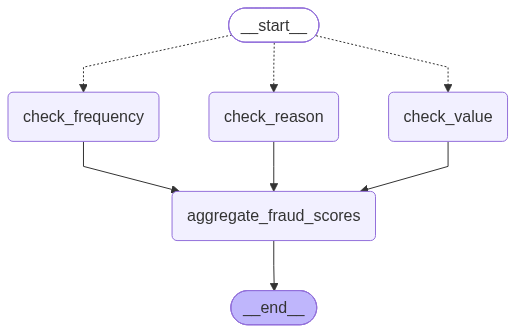

In [ ]:
from IPython.display import Image
Image(fraud_graph.get_graph().draw_mermaid_png())

In [ ]:
good_case = {
    "order_id": "ORD_GOOD_1",
    "user_email": "good_user@example.com",
    "return_reason": "Product arrived damaged",
    "return_items": [{"product_id": "SKU_LAPTOP", "quantity": 1}],
}

bad_case = {
    "order_id": "ORD_BAD_2",
    "user_email": "fraudster@example.com",
    "return_reason": "changed my mind",
    "return_items": [{"product_id": "SKU_WEBCAM", "quantity": 1}],
}

prime_case = {
    "order_id": "ORD_GOOD_2",
    "user_email": "good_user@example.com",
    "return_reason": "changed my mind",
    "return_items": [{"product_id": "SKU_MOUSE", "quantity": 1}],
    "is_prime": True,
}

good_result = fraud_graph.invoke(good_case)
bad_result = fraud_graph.invoke(bad_case)
prime_result = fraud_graph.invoke(prime_case)

print("GOOD USER RESULT")
print(json.dumps(good_result, indent=2))
print("\nBAD USER RESULT")
print(json.dumps(bad_result, indent=2))
print("\nPRIME USER (reason check skipped)")
print(json.dumps(prime_result, indent=2))


[thread] check_return_frequency:[thread] check_order_value_patterns: ThreadPoolExecutor-1_1
 ThreadPoolExecutor-1_0
[thread] check_return_reason_patterns: ThreadPoolExecutor-1_2
